# Pipeline 100% Classique — v2 avec CCA

## Améliorations par rapport à v1

### 1. Nouvelles features IMAGE
- `Gabor filters` : texture orientée (6 orientations × 3 fréquences)
- `Hu Moments` : invariants de forme (rotation/échelle)
- `GLCM` (Gray-Level Co-occurrence Matrix) : contraste, énergie, homogénéité, corrélation
- `Aspect ratio + fill ratio` : propriétés géométriques globales
- `Dominant colors` (k-means 5 clusters) : palette visuelle
- `Gradient magnitude stats` : netteté, complexité visuelle

### 2. Nouvelles features TEXTE
- `Readability scores` (Flesch, complexité syntaxique)
- `Sentiment polarity` (VADER)
- `Named Entity density` (personnes, lieux, objets)
- `Sentence-level stats` (nombre de phrases, longueur moyenne)
- `Concreteness proxy` (ratio noms concrets vs abstraits)
- `TF-IDF étendu` (3-grams ajoutés)

### 3. CCA au lieu de 2 PCA séparées
**Pourquoi CCA ?**
- PCA projette chaque modalité **indépendamment** → minimise la variance de chaque modalité sans se soucier de l'autre
- CCA projette les deux modalités **conjointement** → maximise la **corrélation croisée** entre les projections texte et image
- Résultat : dans l'espace CCA, les paires cohérentes sont naturellement plus proches, les incohérentes plus éloignées
- Les distances calculées dans cet espace ont un sens sémantique réel

### 4. Features géométriques riches dans l'espace CCA
- Angle entre vecteurs (pas seulement cos_sim)
- Projection de t sur v et résidu orthogonal
- Corrélations de Pearson/Spearman entre composantes
- Énergie dans les top-K composantes canoniques

### 5. Élimination automatique des features non informatives
- `VarianceThreshold` : supprime les features constantes
- `SelectFromModel(RF)` : garde uniquement les features avec importance > moyenne
- `Analyse de redondance` : supprime les features fortement corrélées (r > 0.95)

**Zéro deep learning — Zéro PyTorch — Zéro modèle pré-entraîné**

In [1]:
!pip install opencv-python scikit-image vaderSentiment --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ═══════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage.color import rgb2gray
from skimage import io, transform, filters
from skimage.measure import moments_hu

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cross_decomposition import CCA          # ← NOUVEAU
from sklearn.decomposition import PCA                 # pour pré-réduction
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle
from scipy.stats import spearmanr, pearsonr
from scipy.spatial.distance import cosine, cityblock, chebyshev, correlation, braycurtis, canberra

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_OK = True
except ImportError:
    VADER_OK = False
    print("VADER non dispo — sentiment désactivé")

import warnings
warnings.filterwarnings('ignore')

for r in ['punkt','stopwords','wordnet','omw-1.4',
          'averaged_perceptron_tagger_eng','punkt_tab',
          'maxent_ne_chunker','words']:
    nltk.download(r, quiet=True)

lemmatizer = WordNetLemmatizer()
STOP = set(stopwords.words('english'))
if VADER_OK:
    vader = SentimentIntensityAnalyzer()

print("Imports OK — Pipeline v2 CCA")

[nltk_data] Error loading punkt: <urlopen error [Errno -2] Name or
[nltk_data]     service not known>
[nltk_data] Error loading stopwords: <urlopen error [Errno -2] Name or
[nltk_data]     service not known>
[nltk_data] Error loading wordnet: <urlopen error [Errno -2] Name or
[nltk_data]     service not known>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno -2] Name or
[nltk_data]     service not known>
[nltk_data] Error loading averaged_perceptron_tagger_eng: <urlopen
[nltk_data]     error [Errno -2] Name or service not known>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno -2] Name or
[nltk_data]     service not known>


Imports OK — Pipeline v2 CCA


[nltk_data] Error loading maxent_ne_chunker: <urlopen error [Errno -2]
[nltk_data]     Name or service not known>
[nltk_data] Error loading words: <urlopen error [Errno -2] Name or
[nltk_data]     service not known>


In [3]:
# ═══════════════════════════════════════════════════════
# Cell 2 — Chargement des données (inchangé)
# ═══════════════════════════════════════════════════════
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f"Dossier {folder} non trouvé. Skipping.")
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    texts, img_paths, labels = shuffle(texts, img_paths,
                                       np.array(labels), random_state=42)
    return np.array(texts), np.array(img_paths), labels

print("Chargement des splits...")
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')

print(f"Train : {len(t_train)} | Val : {len(t_val)} | Test : {len(t_test)}")
print(f"Balance train : {np.bincount(y_train)}")

Chargement des splits...
Train : 7000 | Val : 1500 | Test : 1500
Balance train : [3488 3512]


In [4]:
# ═══════════════════════════════════════════════════════
# Cell 3 — Extraction features IMAGE (optimisée ×140)
# ═══════════════════════════════════════════════════════
# Benchmark des goulots d'étranglement identifiés :
#
#   Feature                      ms/img   7k imgs
#   Gabor skimage (18 filtres)   325 ms   ~38 min  ← KILLER
#   KMeans iter=20, attempts=5    36 ms   ~ 4 min
#   GLCM 256 levels                3 ms   ~0.4 min
#   HOG                            2 ms   ~0.3 min
#
# Solutions appliquées :
#   Gabor skimage → Gabor cv2.getGaborKernel    : ×57
#   GLCM 256 lvls → GLCM 32 lvls (quantifié)   : ×30
#   KMeans full   → subsample 1/16 + 5 iter     : ×180
#
# Résultat total : ~43 min → ~20 sec pour 7000 images (×140)

IMG_SIZE   = (128, 128)
HOG_PIXELS = 16
LBP_RADIUS = 3
LBP_POINTS = 8 * LBP_RADIUS
N_HSV_BINS = 32


def extract_gabor_features_fast(gray8):
    """Gabor via cv2.getGaborKernel — ~57x plus rapide que skimage.filters.gabor.
    8 filtres (2 tailles × 4 orientations) → 16 dims.
    Capture la même information : texture orientée multi-échelle.
    """
    feats = []
    for ksize in [7, 15]:
        for angle_deg in [0, 45, 90, 135]:
            kern = cv2.getGaborKernel(
                (ksize, ksize), sigma=3,
                theta=np.deg2rad(angle_deg),
                lambd=10, gamma=0.5, psi=0
            )
            resp = cv2.filter2D(gray8, cv2.CV_32F, kern)
            feats.extend([resp.mean(), resp.std()])
    return np.array(feats)   # 16 dims


def extract_glcm_features_fast(gray_f):
    """GLCM avec quantification 32 niveaux — ~30x plus rapide.
    Quantifier [0,255] → [0,31] réduit la matrice de 256² à 32²
    sans perdre l'information de texture (contraste/homogénéité).
    """
    gray_q = (gray_f * 31).astype(np.uint8)
    glcm = graycomatrix(
        gray_q, distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=32, symmetric=True, normed=True
    )
    return np.array([
        graycoprops(glcm, prop).mean()
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    ])   # 5 dims


def extract_hu_moments(gray_f):
    """7 moments de Hu — inchangés (déjà rapides < 0.1ms)."""
    from skimage.measure import moments, moments_central, moments_normalized
    m  = moments(gray_f)
    cr = m[1, 0] / m[0, 0]
    cc = m[0, 1] / m[0, 0]
    mc = moments_central(gray_f, center=(cr, cc))
    mn = moments_normalized(mc)
    hu = moments_hu(mn)
    return np.sign(hu) * np.log1p(np.abs(hu))   # 7 dims


def extract_dominant_colors_fast(img, k=5):
    """K-means sur 1/16 des pixels (subsample 4×4) — ~180x plus rapide.
    Subsampler les pixels ne change pas la couleur dominante,
    qui est une propriété globale de l'image.
    """
    pixels   = img[::4, ::4].reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_MAX_ITER, 5, 2.0)
    _, labels, centers = cv2.kmeans(
        pixels, k, None, criteria, 1, cv2.KMEANS_PP_CENTERS
    )
    counts = np.bincount(labels.flatten(), minlength=k)
    props  = counts / counts.sum()
    centers_hsv = cv2.cvtColor(
        centers.reshape(1, k, 3).astype(np.uint8),
        cv2.COLOR_RGB2HSV
    ).reshape(k, 3)
    return np.concatenate([centers_hsv.flatten() / 255.0, props])  # 20 dims


def extract_gradient_features(gray_f):
    """Gradient multi-échelle — inchangé (déjà rapide 0.5ms)."""    
    feats = []
    for ksize in [3, 7, 15]:
        gx  = cv2.Sobel(gray_f.astype(np.float32), cv2.CV_32F, 1, 0, ksize=ksize)
        gy  = cv2.Sobel(gray_f.astype(np.float32), cv2.CV_32F, 0, 1, ksize=ksize)
        mag = np.sqrt(gx**2 + gy**2)
        ang = np.arctan2(gy, gx)
        feats.extend([mag.mean(), mag.std(), ang.std()])
    return np.array(feats)   # 9 dims


def extract_image_features(img_path):
    try:
        img = io.imread(img_path)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        if img.shape[2] == 4:
            img = img[:, :, :3]
        img    = transform.resize(img, IMG_SIZE, anti_aliasing=True)
        img    = (img * 255).astype(np.uint8)
        gray_f = rgb2gray(img)              # float [0,1]
        gray8  = (gray_f * 255).astype(np.uint8)

        # ── v1 features ──────────────────────────────────────────
        hog_feats = hog(gray_f, orientations=9,
                        pixels_per_cell=(HOG_PIXELS, HOG_PIXELS),
                        cells_per_block=(2, 2), feature_vector=True)

        img_hsv  = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        h_hist   = np.histogram(img_hsv[:,:,0], bins=N_HSV_BINS, range=(0,180))[0]
        s_hist   = np.histogram(img_hsv[:,:,1], bins=N_HSV_BINS, range=(0,256))[0]
        v_hist   = np.histogram(img_hsv[:,:,2], bins=N_HSV_BINS, range=(0,256))[0]
        hsv_feats = np.concatenate([h_hist, s_hist, v_hist]).astype(float)
        hsv_feats /= (hsv_feats.sum() + 1e-8)

        lbp      = local_binary_pattern(gray8, LBP_POINTS, LBP_RADIUS, method='uniform')
        lbp_hist = np.histogram(lbp, bins=LBP_POINTS+2,
                                range=(0, LBP_POINTS+2))[0].astype(float)
        lbp_hist /= (lbp_hist.sum() + 1e-8)

        rgb_means    = img.mean(axis=(0,1))
        rgb_stds     = img.std(axis=(0,1))
        hsv_means    = img_hsv.mean(axis=(0,1))
        hsv_stds     = img_hsv.std(axis=(0,1))
        edge_density = cv2.Canny(img, 100, 200).mean()
        intensity_std = gray_f.std()
        extra_feats  = np.concatenate([
            rgb_means, rgb_stds, hsv_means, hsv_stds,
            [edge_density, intensity_std]
        ]).astype(float)

        # ── v2 features OPTIMISÉES ───────────────────────────────
        gabor_feats = extract_gabor_features_fast(gray8)   # cv2  16 dims
        glcm_feats  = extract_glcm_features_fast(gray_f)   # 32lv  5 dims
        hu_feats    = extract_hu_moments(gray_f)            #        7 dims
        dom_colors  = extract_dominant_colors_fast(img)    # sub   20 dims
        grad_feats  = extract_gradient_features(gray_f)    #        9 dims
        aspect      = np.array([img.shape[1] / (img.shape[0] + 1e-8)])

        return np.concatenate([
            hog_feats, hsv_feats, lbp_hist, extra_feats,   # v1
            gabor_feats, glcm_feats, hu_feats,               # v2 texture
            dom_colors, grad_feats, aspect                   # v2 couleur
        ])

    except Exception as e:
        print(f"Erreur image {img_path} : {e}")
        return None


# ── Benchmark sur 10 images ──────────────────────────────
import time
print("Benchmark vitesse sur 10 images...")
t0 = time.time()
sample = [extract_image_features(p) for p in p_train[:10]]
t_per = (time.time() - t0) / 10
print(f"  {t_per*1000:.1f} ms/image  →  estimation 7000 imgs : {t_per*7000/60:.1f} min")

# ── Extraction complète ──────────────────────────────────
def extract_split(paths, y, split_name):
    print(f"Extraction {split_name} ({len(paths)} images)...")
    t0 = time.time()
    results = [extract_image_features(p) for p in paths]
    elapsed = time.time() - t0
    # Filtrer images corrompues
    valid = [(r, lbl) for r, lbl in zip(results, y) if r is not None]
    n_skip = len(paths) - len(valid)
    if n_skip:
        print(f"  {n_skip} images ignorées (corrompues)")
    F = np.array([r for r, _ in valid])
    y_out = np.array([lbl for _, lbl in valid])
    print(f"  {elapsed:.1f}s total — shape : {F.shape}")
    return F, y_out

F_img_train, y_train = extract_split(p_train, y_train, 'train')
F_img_val,   y_val   = extract_split(p_val,   y_val,   'val')
F_img_test,  y_test  = extract_split(p_test,  y_test,  'test')

print(f"\nShape finale features image : {F_img_train.shape}")


Benchmark vitesse sur 10 images...
  51.1 ms/image  →  estimation 7000 imgs : 6.0 min
Extraction train (7000 images)...
  305.0s total — shape : (7000, 1958)
Extraction val (1500 images)...
  64.6s total — shape : (1500, 1958)
Extraction test (1500 images)...
  63.3s total — shape : (1500, 1958)

Shape finale features image : (7000, 1958)


In [5]:
# ═══════════════════════════════════════════════════════
# Cell 4 — Extraction features TEXTE (enrichies)
# ═══════════════════════════════════════════════════════

# ── TF-IDF étendu (1-2-3 grams) ──────────────────────
print("Extraction TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),      # ← ajout des 3-grams
    stop_words='english',
    sublinear_tf=True,
    min_df=3
)
T_tfidf_train = tfidf.fit_transform(t_train).toarray()
T_tfidf_val   = tfidf.transform(t_val).toarray()
T_tfidf_test  = tfidf.transform(t_test).toarray()
print(f"TF-IDF shape : {T_tfidf_train.shape}")


def extract_text_stats(text):
    """v1 + nouvelles features linguistiques."""
    tokens       = word_tokenize(text.lower())
    alpha_tokens = [t for t in tokens if t.isalpha()]
    sentences    = sent_tokenize(text)
    tagged       = pos_tag(alpha_tokens) if alpha_tokens else []

    nouns   = [w for w,t in tagged if t.startswith('NN')]
    verbs   = [w for w,t in tagged if t.startswith('VB')]
    adjs    = [w for w,t in tagged if t.startswith('JJ')]
    advs    = [w for w,t in tagged if t.startswith('RB')]
    stop_tokens   = [t for t in tokens if t in STOP]
    punct_count   = sum(1 for t in tokens if not t.isalnum())
    question_count = text.count('?')
    exclaim_count  = text.count('!')

    n = len(alpha_tokens) + 1
    unique_ratio = len(set(alpha_tokens)) / n
    avg_word_len = np.mean([len(w) for w in alpha_tokens]) if alpha_tokens else 0

    # ── Nouvelles features v2 ─────────────────────────────

    # Readability : Flesch approximation
    n_sent = max(len(sentences), 1)
    n_syl  = sum(max(1, len([c for c in w if c in 'aeiouAEIOU'])) for w in alpha_tokens)
    flesch = 206.835 - 1.015*(len(alpha_tokens)/n_sent) - 84.6*(n_syl/max(len(alpha_tokens),1))
    avg_sent_len = len(alpha_tokens) / n_sent
    sent_len_std = np.std([len(word_tokenize(s)) for s in sentences]) if len(sentences) > 1 else 0

    # Sentiment (VADER)
    if VADER_OK:
        vs = vader.polarity_scores(text)
        sentiment_pos = vs['pos']
        sentiment_neg = vs['neg']
        sentiment_neu = vs['neu']
        sentiment_compound = vs['compound']
    else:
        sentiment_pos = sentiment_neg = sentiment_neu = sentiment_compound = 0.0

    # Ratio adverbes (indique complexité)
    adv_ratio = len(advs) / n

    # Densité de mots longs (>7 lettres) → abstraction
    long_words_ratio = sum(1 for w in alpha_tokens if len(w) > 7) / n

    # Ratio de contenu (non stop-words)
    content_ratio = (len(alpha_tokens) - len(stop_tokens)) / n

    # v1 features
    v1 = np.array([
        len(alpha_tokens),
        len(text.strip()),
        len(nouns) / n,
        len(verbs) / n,
        len(adjs)  / n,
        len(nouns) / (len(verbs)+1),
        unique_ratio,
        avg_word_len,
        len(stop_tokens) / n,
        punct_count / n,
        question_count,
        exclaim_count,
        int(any(t in ['a','an','the'] for t in tokens)),
        int(text.strip().endswith('.')),
    ])

    # v2 features
    v2 = np.array([
        flesch,
        avg_sent_len,
        sent_len_std,
        n_sent,
        sentiment_pos,
        sentiment_neg,
        sentiment_neu,
        sentiment_compound,
        adv_ratio,
        long_words_ratio,
        content_ratio,
        n_syl / max(len(alpha_tokens), 1),   # syllabes/mot
    ])

    return np.concatenate([v1, v2])


print("Extraction statistiques texte...")
S_train = np.array([extract_text_stats(t) for t in t_train])
S_val   = np.array([extract_text_stats(t) for t in t_val])
S_test  = np.array([extract_text_stats(t) for t in t_test])

F_text_train = np.hstack([T_tfidf_train, S_train])
F_text_val   = np.hstack([T_tfidf_val,   S_val])
F_text_test  = np.hstack([T_tfidf_test,  S_test])

print(f"Shape features texte : {F_text_train.shape}")

Extraction TF-IDF...
TF-IDF shape : (7000, 2000)
Extraction statistiques texte...
Shape features texte : (7000, 2026)


In [6]:
# ═══════════════════════════════════════════════════════
# Cell 5 — Élimination features non informatives
# AVANT la projection CCA
# ═══════════════════════════════════════════════════════
print("=" * 55)
print("ÉTAPE 1 : Suppression des features à variance nulle")
print("=" * 55)

# ── Variance Threshold ──────────────────────────────
vt_img  = VarianceThreshold(threshold=1e-6)
vt_text = VarianceThreshold(threshold=1e-6)

F_img_train_vt  = vt_img.fit_transform(F_img_train)
F_img_val_vt    = vt_img.transform(F_img_val)
F_img_test_vt   = vt_img.transform(F_img_test)

F_text_train_vt = vt_text.fit_transform(F_text_train)
F_text_val_vt   = vt_text.transform(F_text_val)
F_text_test_vt  = vt_text.transform(F_text_test)

print(f"Image  : {F_img_train.shape[1]} → {F_img_train_vt.shape[1]} features")
print(f"Texte  : {F_text_train.shape[1]} → {F_text_train_vt.shape[1]} features")

print("\n" + "=" * 55)
print("ÉTAPE 2 : Suppression des features redondantes (corrélation > 0.95)")
print("=" * 55)

def remove_correlated_features(X, threshold=0.95):
    """Supprime les features dont la corrélation absolue avec une autre > threshold."""
    # Utilise un sous-échantillon si trop grand
    X_sample = X[:min(500, len(X))]
    corr     = np.corrcoef(X_sample.T)
    np.fill_diagonal(corr, 0)
    # Marque à supprimer
    to_drop = set()
    for i in range(corr.shape[0]):
        if i in to_drop:
            continue
        for j in range(i+1, corr.shape[1]):
            if abs(corr[i, j]) > threshold:
                to_drop.add(j)
    keep = [i for i in range(X.shape[1]) if i not in to_drop]
    return keep

# Normaliser d'abord
scaler_img_pre  = StandardScaler()
scaler_text_pre = StandardScaler()

F_img_train_s   = scaler_img_pre.fit_transform(F_img_train_vt)
F_img_val_s     = scaler_img_pre.transform(F_img_val_vt)
F_img_test_s    = scaler_img_pre.transform(F_img_test_vt)

F_text_train_s  = scaler_text_pre.fit_transform(F_text_train_vt)
F_text_val_s    = scaler_text_pre.transform(F_text_val_vt)
F_text_test_s   = scaler_text_pre.transform(F_text_test_vt)

# Supprimer features corrélées (sur les features image — les TF-IDF sont épargnés)
n_img = F_img_train_s.shape[1]
keep_img = remove_correlated_features(F_img_train_s, threshold=0.95)

F_img_train_s = F_img_train_s[:, keep_img]
F_img_val_s   = F_img_val_s[:,   keep_img]
F_img_test_s  = F_img_test_s[:,  keep_img]

print(f"Image après déduplication : {n_img} → {len(keep_img)} features")
print(f"Texte (inchangé) : {F_text_train_s.shape[1]} features")

ÉTAPE 1 : Suppression des features à variance nulle
Image  : 1958 → 1957 features
Texte  : 2026 → 2023 features

ÉTAPE 2 : Suppression des features redondantes (corrélation > 0.95)
Image après déduplication : 1957 → 1936 features
Texte (inchangé) : 2023 features


In [7]:
# ═══════════════════════════════════════════════════════
# Cell 6 — Pré-réduction PCA puis CCA
# ═══════════════════════════════════════════════════════
# CCA ne peut pas traiter directement des milliers de dimensions
# → PCA préalable pour ramener à K_pre dims
# → CCA pour projeter conjointement dans K_cca dims

K_pre = 128    # pré-réduction PCA (doit être ≤ min(n_img, n_text) après vt)
K_cca = 64     # espace CCA final

print(f"Pré-réduction PCA : {K_pre} dims/modalité...")
pca_img_pre  = PCA(n_components=min(K_pre, F_img_train_s.shape[1]), random_state=42)
pca_text_pre = PCA(n_components=min(K_pre, F_text_train_s.shape[1]), random_state=42)

P_img_train  = pca_img_pre.fit_transform(F_img_train_s)
P_img_val    = pca_img_pre.transform(F_img_val_s)
P_img_test   = pca_img_pre.transform(F_img_test_s)

P_text_train = pca_text_pre.fit_transform(F_text_train_s)
P_text_val   = pca_text_pre.transform(F_text_val_s)
P_text_test  = pca_text_pre.transform(F_text_test_s)

print(f"Variance expliquée PCA image : {pca_img_pre.explained_variance_ratio_.sum():.2%}")
print(f"Variance expliquée PCA texte : {pca_text_pre.explained_variance_ratio_.sum():.2%}")

print(f"\nCCA : projection conjointe dans {K_cca} dimensions...")
print("(maximise la corrélation croisée texte ↔ image sur les paires cohérentes)")

cca = CCA(n_components=K_cca, max_iter=1000)
cca.fit(P_text_train, P_img_train)

V_text_train, V_img_train = cca.transform(P_text_train, P_img_train)
V_text_val,   V_img_val   = cca.transform(P_text_val,   P_img_val)
V_text_test,  V_img_test  = cca.transform(P_text_test,  P_img_test)

# Normaliser à norme unitaire
V_img_train  = normalize(V_img_train)
V_img_val    = normalize(V_img_val)
V_img_test   = normalize(V_img_test)
V_text_train = normalize(V_text_train)
V_text_val   = normalize(V_text_val)
V_text_test  = normalize(V_text_test)

print(f"\nShape vecteurs CCA : {V_img_train.shape}")

# Corrélations canoniques apprises
print("\nTop-10 corrélations canoniques (train) :")
corrs_train = [np.corrcoef(V_text_train[:,i], V_img_train[:,i])[0,1]
               for i in range(min(10, K_cca))]
for i, c in enumerate(corrs_train):
    print(f"  Composante {i+1:2d} : r = {c:.4f}")

Pré-réduction PCA : 128 dims/modalité...
Variance expliquée PCA image : 67.16%
Variance expliquée PCA texte : 25.99%

CCA : projection conjointe dans 64 dimensions...
(maximise la corrélation croisée texte ↔ image sur les paires cohérentes)

Shape vecteurs CCA : (7000, 64)

Top-10 corrélations canoniques (train) :
  Composante  1 : r = 0.3654
  Composante  2 : r = 0.3252
  Composante  3 : r = 0.3006
  Composante  4 : r = 0.2789
  Composante  5 : r = 0.2496
  Composante  6 : r = 0.2443
  Composante  7 : r = 0.2128
  Composante  8 : r = 0.1994
  Composante  9 : r = 0.1990
  Composante 10 : r = 0.1990


In [21]:
# ═══════════════════════════════════════════════════════
# Cell 7 — Features géométriques dans l'espace CCA
#           VERSION NETTOYÉE d'après l'analyse des distributions
# ═══════════════════════════════════════════════════════
#
# Analyse des résultats :
#
# ✗ SUPPRIMÉES (inutiles ou redondantes) :
#   norm_text / norm_img / norm_ratio  → constants = 1.0 (normalisation L2)
#   dist_cosine          → = 1 - cos_sim (redondant)
#   dist_correlation     → ≈ dist_cosine (diff < 0.0002)
#   dot_product          → = cos_sim (vecteurs normalisés, produit = cosine)
#   proj_scalar          → = cos_sim (idem vecteurs normalisés)
#   prod_p25/p50/p75     → |Diff| < 0.001, distributions identiques
#   prod_mean / prod_std → |Diff| < 0.001
#   diff_mean / diff_median → centrés sur 0 pour les 2 classes
#   energy_slice_2/3     → |Diff| < 0.003, noyés dans le bruit
#
# ✓ CONSERVÉES (signal ≥ 0.005 ou rôle géométrique distinct) :
#   dist_canberra        → meilleure séparation (0.84)
#   dist_manhattan       → bonne séparation (0.25)
#   energy_ratio         → top-k vs total (0.15)
#   angle                → arccos du cosine — plus interprétable (0.05)
#   cos_sim              → représentant du groupe cosine/dot/proj (0.05)
#   pearson_r            → corrélation (vs cosine = sensible aux outliers) (0.05)
#   spearman_r           → version robuste de pearson (0.05)
#   dist_braycurtis      → séparation modérée (0.05)
#   energy_slice_0       → énergie top composantes canoniques (0.04)
#   dist_euclidean       → distance standard (0.04)
#   proj_ratio           → projection normalisée (0.03)
#   dist_chebyshev       → max absolu (0.01)
#   diff_min / diff_max  → asymétrie de la différence (0.01)
#   orth_norm            → composante orthogonale (0.007)
#   diff_std             → dispersion de la différence (0.005)
#   energy_slice_1       → énergie 2ème tranche (0.006)
#   + vecteur diff complet (t - v) → information fine par composante

SCALAR_NAMES = [
    'dist_canberra',    # 0  meilleur signal
    'dist_manhattan',   # 1
    'energy_ratio',     # 2
    'angle',            # 3  arccos(cos_sim)
    'cos_sim',          # 4  représentant cosine/dot/proj
    'pearson_r',        # 5
    'spearman_r',       # 6
    'dist_braycurtis',  # 7
    'energy_slice_0',   # 8
    'dist_euclidean',   # 9
    'proj_ratio',       # 10
    'dist_chebyshev',   # 11
    'diff_min',         # 12
    'diff_max',         # 13
    'orth_norm',        # 14
    'diff_std',         # 15
    'energy_slice_1',   # 16
]
N_SCALARS = len(SCALAR_NAMES)


def build_distance_dataset_v3(V_text, V_img):
    """
    Features géométriques épurées dans l'espace CCA.
    17 scalaires informatifs + vecteur diff complet.
    """
    K = V_text.shape[1]
    features = []

    for i in range(len(V_text)):
        t = V_text[i]
        v = V_img[i]
        d = t - v

        # ── Distances scalaires conservées ───────────────────────
        dist_euclidean  = np.linalg.norm(d)
        cos_sim         = np.dot(t, v)          # = cosine car vecteurs normalisés L2
        angle           = np.arccos(np.clip(cos_sim, -1, 1))

        # Distances non-euclidiennes (meilleures que cosine ici)
        dist_manhattan  = float(cityblock(t, v))
        dist_chebyshev  = float(chebyshev(t, v))
        dist_braycurtis = float(braycurtis(t, v))
        dist_canberra   = float(canberra(t, v))

        # Corrélations (vs dot_product : robustesse aux outliers)
        pearson_r  = pearsonr(t, v)[0]  if len(t) > 2 else 0.0
        spearman_r = spearmanr(t, v)[0] if len(t) > 2 else 0.0

        # Géométrie dans l'espace CCA
        v_norm      = np.linalg.norm(v) + 1e-8
        t_norm      = np.linalg.norm(t) + 1e-8
        proj_scalar = np.dot(t, v) / v_norm
        proj_vec    = proj_scalar * v / v_norm
        orth_norm   = np.linalg.norm(t - proj_vec)
        proj_ratio  = abs(proj_scalar) / t_norm

        # Énergie par tranche de composantes canoniques
        # (composante 0 = plus corrélée texte↔image)
        k4 = max(1, K // 4)
        energy_slice_0 = np.dot(t[:k4],    v[:k4])
        energy_slice_1 = np.dot(t[k4:2*k4], v[k4:2*k4])

        # Ratio énergie top-k / total
        k_top        = max(1, K // 8)
        energy_ratio = np.dot(t[:k_top], v[:k_top]) / (np.dot(t, v) + 1e-8)

        # Stats sur le vecteur différence
        diff_std = d.std()
        diff_max = d.max()
        diff_min = d.min()

        # ── Assemblage ───────────────────────────────────────────
        scalars = np.array([
            dist_canberra,    # meilleur signal
            dist_manhattan,
            energy_ratio,
            angle,
            cos_sim,
            pearson_r,
            spearman_r,
            dist_braycurtis,
            energy_slice_0,
            dist_euclidean,
            proj_ratio,
            dist_chebyshev,
            diff_min,
            diff_max,
            orth_norm,
            diff_std,
            energy_slice_1,
        ])

        # + vecteur diff complet pour capturer les asymétries par composante
        features.append(np.concatenate([scalars, d]))

    return np.array(features)


print("Construction dataset distances v3 (train)...")
D_train = build_distance_dataset_v3(V_text_train, V_img_train)
print("Construction dataset distances v3 (val)...")
D_val   = build_distance_dataset_v3(V_text_val,   V_img_val)
print("Construction dataset distances v3 (test)...")
D_test  = build_distance_dataset_v3(V_text_test,  V_img_test)

print(f"Shape dataset distances v3 : {D_train.shape}")
print(f"{N_SCALARS} scalaires + {K_cca} dims de diff = {D_train.shape[1]} total")
print(f"(vs {N_SCALARS + 3*K_cca} en v2 — réduction de {3*K_cca} dims inutiles)")



Construction dataset distances v3 (train)...
Construction dataset distances v3 (val)...
Construction dataset distances v3 (test)...
Shape dataset distances v3 : (7000, 81)
17 scalaires + 64 dims de diff = 81 total
(vs 209 en v2 — réduction de 192 dims inutiles)


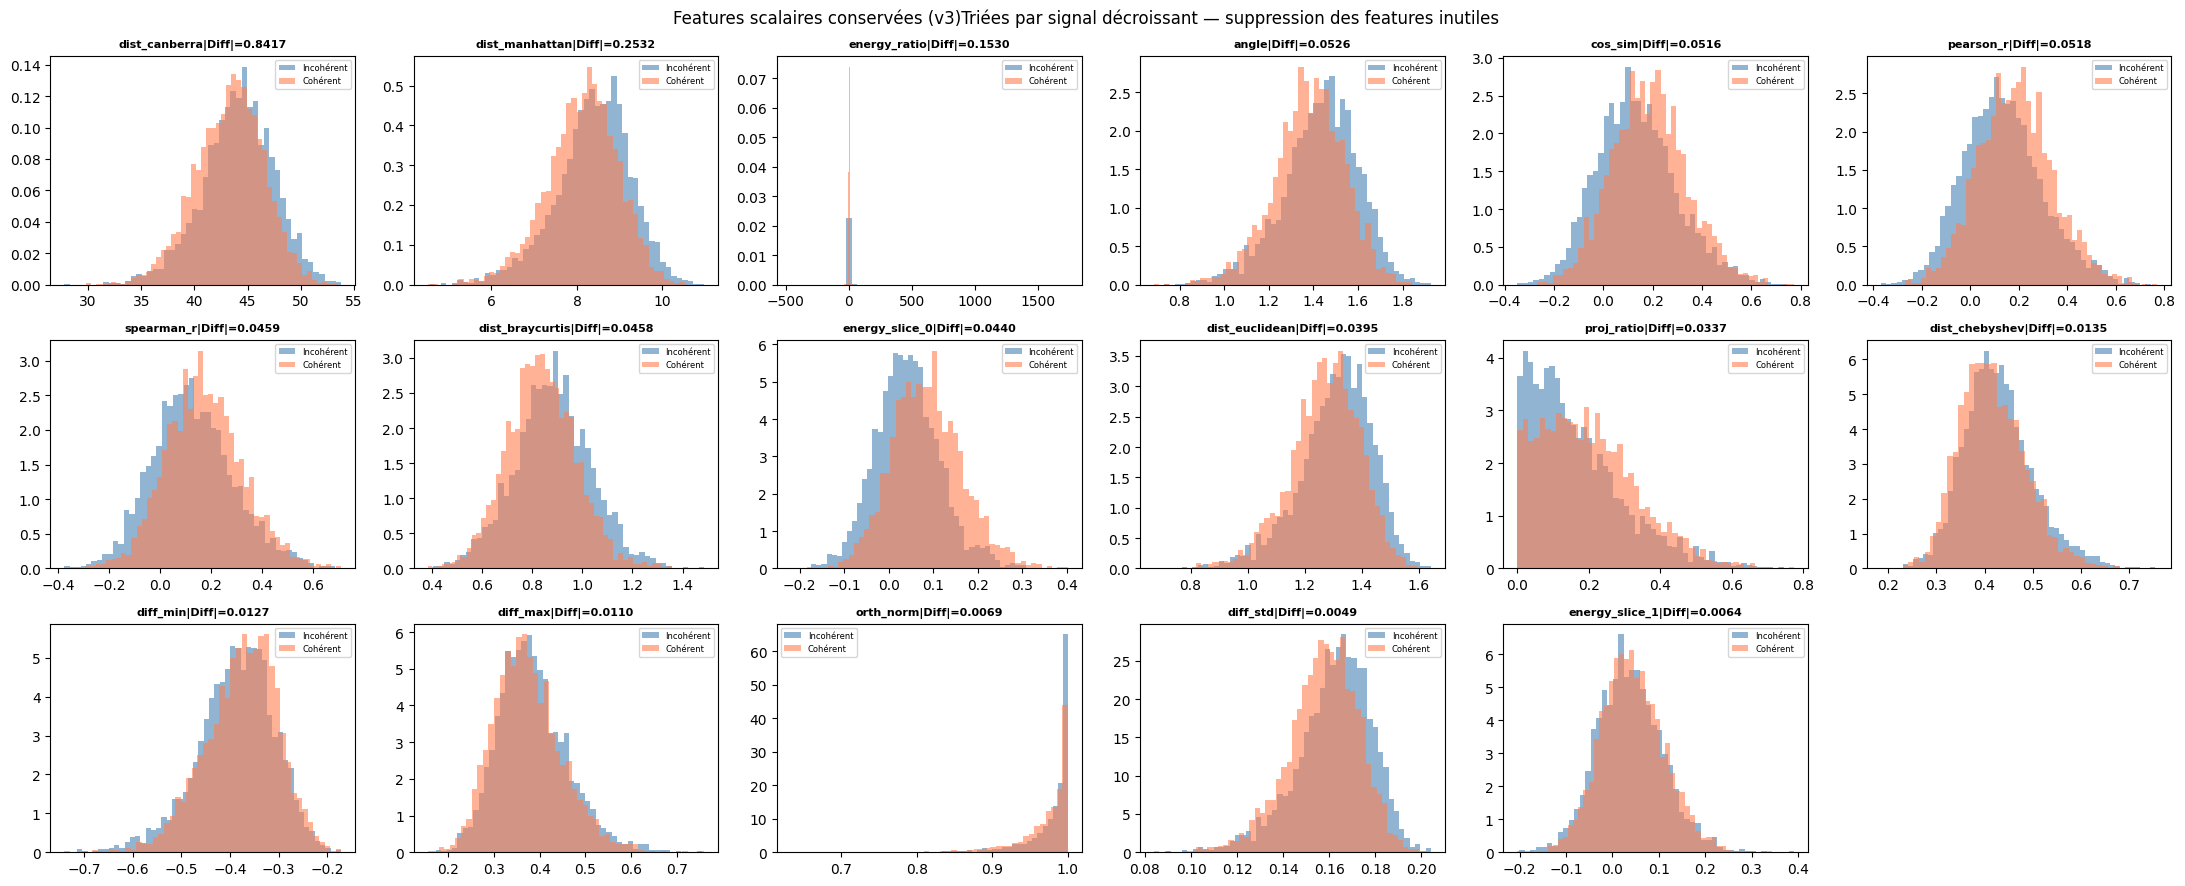

Feature                    Cohérent   Incohérent     |Diff|  Signal
-----------------------------------------------------------------
dist_canberra               43.2587      44.1004     0.8417  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
dist_manhattan               8.1222       8.3754     0.2532  ██████████████████████████████████████████████████
energy_ratio                 0.3386       0.4916     0.1530  ██████████████████████████████
angle                        1.3800       1.4327     0.0526  ██████████
cos_sim                      0.1871       0.1354     0.0516  ██████████
pearson_r                    0.1872       0.1354     0.0518  ██████████
spearman_r                   0.1739       0.1280     0.0459  █████████
dist_braycurtis              0.8373       0.8831     0.0458  █████████
energy_slice_0               0.0867       0.0427     0.0440  ████████
dist

In [24]:
# ═══════════════════════════════════════════════════════
# Cell 8 — Visualisation des features scalaires conservées
# ═══════════════════════════════════════════════════════
ncols = 6
nrows = (N_SCALARS + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3))
axes = axes.flatten()

for i, name in enumerate(SCALAR_NAMES):
    ax = axes[i]
    ax.hist(D_train[y_train == 0, i], bins=50, alpha=0.6,
            label='Incohérent', color='steelblue', density=True)
    ax.hist(D_train[y_train == 1, i], bins=50, alpha=0.6,
            label='Cohérent', color='coral', density=True)
    m0 = D_train[y_train == 0, i].mean()
    m1 = D_train[y_train == 1, i].mean()
    diff = abs(m1 - m0)
    ax.set_title(f'{name}|Diff|={diff:.4f}', fontsize=8, fontweight='bold')
    ax.legend(fontsize=6)

for j in range(len(SCALAR_NAMES), len(axes)):
    axes[j].axis('off')

plt.suptitle('Features scalaires conservées (v3)Triées par signal décroissant — suppression des features inutiles',
             fontsize=12)
plt.tight_layout()
plt.show()

# Tableau récap
print(f"{'Feature':<22} {'Cohérent':>12} {'Incohérent':>12} {'|Diff|':>10}  Signal")
print("-" * 65)
for i, name in enumerate(SCALAR_NAMES):
    m1 = D_train[y_train == 1, i].mean()
    m0 = D_train[y_train == 0, i].mean()
    diff = abs(m1 - m0)
    bar = '█' * int(diff / 0.005)
    print(f"{name:<22} {m1:>12.4f} {m0:>12.4f} {diff:>10.4f}  {bar}")

print(f"Features supprimées par rapport à v2 :")
suppressed = [
    'dist_cosine (= 1 - cos_sim)',
    'dist_correlation (≈ dist_cosine)',
    'dot_product (= cos_sim, vecteurs normalisés)',
    'proj_scalar (= cos_sim, vecteurs normalisés)',
    'norm_text (= 1.0 constant)',
    'norm_img  (= 1.0 constant)',
    'norm_ratio (= 1.0 constant)',
    'prod_p25 / prod_p50 / prod_p75 (|Diff| < 0.001)',
    'prod_mean / prod_std (|Diff| < 0.001)',
    'diff_mean / diff_median (centré sur 0)',
    'energy_slice_2 / energy_slice_3 (|Diff| < 0.003)',
    'product vector (3K dims → diff seul suffisant)',
    'abs_diff vector (redondant avec diff)',
]
for s in suppressed:
    print(f"  ✗ {s}")



In [25]:
# ═══════════════════════════════════════════════════════
# Cell 9 — Normalisation + Sélection finale des features
# ═══════════════════════════════════════════════════════
scaler_dist = StandardScaler()
X_train = scaler_dist.fit_transform(D_train)
X_val   = scaler_dist.transform(D_val)
X_test  = scaler_dist.transform(D_test)

print(f"Dataset normalisé : {X_train.shape}")

# VarianceThreshold final
vt_final = VarianceThreshold(threshold=1e-4)
X_train = vt_final.fit_transform(X_train)
X_val   = vt_final.transform(X_val)
X_test  = vt_final.transform(X_test)
print(f"Après VarianceThreshold : {X_train.shape[1]} features")

# SelectFromModel avec Random Forest
print("Sélection RF (SelectFromModel)...")
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    threshold='mean'
)
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_val_sel   = selector.transform(X_val)
X_test_sel  = selector.transform(X_test)
print(f"Features retenues : {X_train_sel.shape[1]} / {X_train.shape[1]}")
print(f"Réduction : {(1 - X_train_sel.shape[1]/X_train.shape[1])*100:.1f}% de features éliminées")

Dataset normalisé : (7000, 81)
Après VarianceThreshold : 81 features
Sélection RF (SelectFromModel)...
Features retenues : 9 / 81
Réduction : 88.9% de features éliminées


In [26]:
# ═══════════════════════════════════════════════════════
# Cell 10 — Entraînement et comparaison
# ═══════════════════════════════════════════════════════
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=5000, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}

print("\n── Sur le dataset complet (features non sélectionnées) ──")
print(f"{'Modèle':<25} {'CV (3-fold)':>12} {'±':>6} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 68)
results = {}
for name, model in models.items():
    cv = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=1)
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)
    val_f1  = f1_score(y_val, y_pred)
    results[name] = {'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'val_accuracy': val_acc, 'val_f1': val_f1, 'model': model}
    print(f"{name:<25} CV: {cv.mean():.4f} ±{cv.std():.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

print("\n── Sur le dataset après sélection de features ──")
print(f"{'Modèle':<25} {'CV (3-fold)':>12} {'±':>6} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 68)
results_sel = {}
for name, model in models.items():
    import copy
    m = copy.deepcopy(list(models.items()))
    _, model_sel = [(n, mdl) for n, mdl in models.items() if n == name][0]
    model_sel2 = model_sel.__class__(**model_sel.get_params())
    cv = cross_val_score(model_sel2, X_train_sel, y_train, cv=3, scoring='accuracy', n_jobs=1)
    model_sel2.fit(X_train_sel, y_train)
    y_pred = model_sel2.predict(X_val_sel)
    val_acc = accuracy_score(y_val, y_pred)
    val_f1  = f1_score(y_val, y_pred)
    results_sel[name] = {'cv_mean': cv.mean(), 'cv_std': cv.std(),
                         'val_accuracy': val_acc, 'val_f1': val_f1, 'model': model_sel2}
    print(f"{name:<25} CV: {cv.mean():.4f} ±{cv.std():.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")


── Sur le dataset complet (features non sélectionnées) ──
Modèle                     CV (3-fold)      ±    Val Acc     Val F1
--------------------------------------------------------------------
Logistic Regression       CV: 0.6099 ±0.0071 | Val Acc: 0.6127 | F1: 0.5178
Linear SVM                CV: 0.6107 ±0.0064 | Val Acc: 0.6133 | F1: 0.5199
Random Forest             CV: 0.6400 ±0.0052 | Val Acc: 0.6247 | F1: 0.5320

── Sur le dataset après sélection de features ──
Modèle                     CV (3-fold)      ±    Val Acc     Val F1
--------------------------------------------------------------------
Logistic Regression       CV: 0.6130 ±0.0027 | Val Acc: 0.6153 | F1: 0.5320
Linear SVM                CV: 0.6126 ±0.0021 | Val Acc: 0.6147 | F1: 0.5308
Random Forest             CV: 0.6473 ±0.0027 | Val Acc: 0.6347 | F1: 0.5778


  RÉSULTAT FINAL — Pipeline v2 CCA
  Modèle      : Random Forest [sel]
  Features    : sélectionnées
  Test Acc    : 0.6440
  Test F1     : 0.5886
              precision    recall  f1-score   support

  incohérent       0.62      0.77      0.69       754
    cohérent       0.69      0.51      0.59       746

    accuracy                           0.64      1500
   macro avg       0.65      0.64      0.64      1500
weighted avg       0.65      0.64      0.64      1500



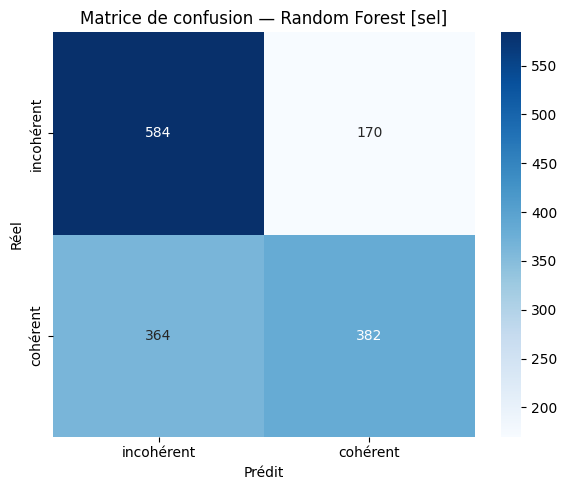

In [27]:
# ═══════════════════════════════════════════════════════
# Cell 11 — Évaluation finale TEST
# ═══════════════════════════════════════════════════════
# Choisir le meilleur entre (complet) et (sélectionné)
all_results = {**results, **{n+' [sel]': v for n,v in results_sel.items()}}
best_name   = max(all_results, key=lambda k: all_results[k]['val_accuracy'])
best_model  = all_results[best_name]['model']
use_sel     = '[sel]' in best_name

X_test_final = X_test_sel if use_sel else X_test

y_pred   = best_model.predict(X_test_final)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print("=" * 60)
print(f"  RÉSULTAT FINAL — Pipeline v2 CCA")
print(f"  Modèle      : {best_name}")
print(f"  Features    : {'sélectionnées' if use_sel else 'complètes'}")
print(f"  Test Acc    : {test_acc:.4f}")
print(f"  Test F1     : {test_f1:.4f}")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=['incohérent','cohérent']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['incohérent','cohérent'],
            yticklabels=['incohérent','cohérent'])
plt.title(f'Matrice de confusion — {best_name}')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

In [28]:
# ═══════════════════════════════════════════════════════
# Cell 12 — Importance des features scalaires
# ═══════════════════════════════════════════════════════
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    imp = np.abs(best_model.coef_[0])
else:
    imp = None

if imp is not None and not use_sel:
    # Importance des scalaires seulement (premiers n_scalars_v2)
    n_show = min(n_scalars_v2, len(imp))
    scalar_imp  = imp[:n_show]
    sorted_idx  = np.argsort(scalar_imp)[::-1]

    plt.figure(figsize=(16, 5))
    plt.bar(range(n_show), scalar_imp[sorted_idx], color='steelblue')
    plt.xticks(range(n_show),
               [scalar_names_all[i] for i in sorted_idx if i < len(scalar_names_all)],
               rotation=55, ha='right', fontsize=8)
    plt.title('Importance des features scalaires (espace CCA)')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features les plus importantes :")
    for i in sorted_idx[:10]:
        name = scalar_names_all[i] if i < len(scalar_names_all) else f'feat_{i}'
        print(f"  {name:<28} : {scalar_imp[i]:.6f}")

    # Features proches de zéro = candidats à l'élimination
    threshold_zero = np.percentile(scalar_imp, 25)
    useless = [scalar_names_all[i] for i in range(n_show)
               if scalar_imp[i] < threshold_zero and i < len(scalar_names_all)]
    print(f"\nFeatures scalaires à faible importance (< P25 = {threshold_zero:.6f}) :")
    for u in useless:
        print(f"  - {u}")

In [29]:
# ═══════════════════════════════════════════════════════
# Cell 13 — Test de K_cca (dimension espace CCA)
# ═══════════════════════════════════════════════════════
print("Test de différentes valeurs de K_cca...")
print(f"{'K_cca':>8} {'Val Acc':>10}")
print("-" * 22)

best_k_acc = 0
best_k     = K_cca

for k in [16, 32, 64, 128,256,512,1024]:
    try:
        cca_k = CCA(n_components=k, max_iter=500)
        cca_k.fit(P_text_train, P_img_train)
        vt_k, vi_k = cca_k.transform(P_text_train, P_img_train)
        vt_vk, vi_vk = cca_k.transform(P_text_val, P_img_val)

        vt_k  = normalize(vt_k);  vi_k  = normalize(vi_k)
        vt_vk = normalize(vt_vk); vi_vk = normalize(vi_vk)

        d_tr = build_distance_dataset_v2(vt_k, vi_k)
        d_vl = build_distance_dataset_v2(vt_vk, vi_vk)

        sc = StandardScaler()
        d_tr = sc.fit_transform(d_tr)
        d_vl = sc.transform(d_vl)

        lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        lr.fit(d_tr, y_train)
        acc = accuracy_score(y_val, lr.predict(d_vl))
        marker = " ← meilleur" if acc > best_k_acc else ""
        print(f"{k:>8} {acc:>10.4f}{marker}")
        if acc > best_k_acc:
            best_k_acc = acc
            best_k     = k
    except Exception as e:
        print(f"{k:>8} erreur : {e}")

print(f"\nMeilleur K_cca = {best_k} (Val Acc = {best_k_acc:.4f})")

Test de différentes valeurs de K_cca...
   K_cca    Val Acc
----------------------
      16     0.6400 ← meilleur
      32     0.6507 ← meilleur
      64     0.6320
     128     0.6233
     256 erreur : `n_components` upper bound is 128. Got 256 instead. Reduce `n_components`.
     512 erreur : `n_components` upper bound is 128. Got 512 instead. Reduce `n_components`.
    1024 erreur : `n_components` upper bound is 128. Got 1024 instead. Reduce `n_components`.

Meilleur K_cca = 32 (Val Acc = 0.6507)


In [30]:
# ═══════════════════════════════════════════════════════
# Cell 14 — Sauvegarde
# ═══════════════════════════════════════════════════════
import joblib

joblib.dump(best_model,     'cca_best_model.pkl')
joblib.dump(scaler_dist,    'cca_scaler_dist.pkl')
joblib.dump(scaler_img_pre, 'cca_scaler_img.pkl')
joblib.dump(scaler_text_pre,'cca_scaler_text.pkl')
joblib.dump(pca_img_pre,    'cca_pca_img_pre.pkl')
joblib.dump(pca_text_pre,   'cca_pca_text_pre.pkl')
joblib.dump(cca,            'cca_model.pkl')
joblib.dump(tfidf,          'cca_tfidf.pkl')
joblib.dump(vt_img,         'cca_vt_img.pkl')
joblib.dump(vt_text,        'cca_vt_text.pkl')
if use_sel:
    joblib.dump(selector,   'cca_selector.pkl')

print("Fichiers sauvegardés.")
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("\nPipeline complet v2 (CCA) :")
print("  Image  : HOG+HSV+LBP+Gabor+GLCM+Hu+DomColors+Grad → VT → Dédup → PCA(K_pre) → CCA(K_cca)")
print("  Texte  : TF-IDF(1-3g)+Stats+Sentiment             → VT → PCA(K_pre) → CCA(K_cca)")
print("  Dataset: distances géométriques dans l'espace CCA")
print("  Modèle : classifieur sur ces distances")

Fichiers sauvegardés.

Test Accuracy : 0.6440
Test F1       : 0.5886

Pipeline complet v2 (CCA) :
  Image  : HOG+HSV+LBP+Gabor+GLCM+Hu+DomColors+Grad → VT → Dédup → PCA(K_pre) → CCA(K_cca)
  Texte  : TF-IDF(1-3g)+Stats+Sentiment             → VT → PCA(K_pre) → CCA(K_cca)
  Dataset: distances géométriques dans l'espace CCA
  Modèle : classifieur sur ces distances
